In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Scikit-Learn: model selection and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, auc, f1_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# Handling imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output
sns.set_style("whitegrid")
# Initialize list to store model results
model_results = [] 

In [ ]:
# Data loading
file_path = "Projet-machine-learning\\data.csv"

try:
    data = pd.read_csv(file_path)
    print(f"Dataset loaded: {data.shape}") # Print dataset's shape if loaded
except FileNotFoundError:
    print(f"Error: '{file_path}' not found in the current directory.")

# Standardize column names
data.columns = data.columns.str.strip().str.replace(" " ,"_") # removing spaces at the beginning and the end. Replacing other spaces with underscores
data.rename(columns = {'Bankrupt?' :'Bankrupt' }, inplace=True) # Rename column 'bankrupt?' to 'bankrupt'

# Drop constant or unnecessary columns
if 'Net_Income_Flag' in data.columns:
    data.drop(['Net_Income_Flag'], axis=1, inplace=True)

# Logarithmic transformation for skewed features to reduce skewness
# Identifying columns with values between 0 and 1 (fractions) vs larger values
fractional_columns = []
for col in data.drop(['Bankrupt'], axis=1).columns:
    if (data[col].max()<=1) & (data[col].min() >= 0):
        fractional_columns.append(col)

non_fraction_columns = data.drop(['Bankrupt'], axis=1).columns.difference(fractional_columns)

# Apply log1p only to columns with outliers or extreme values
# Iterate through the non-fractional columns to check for skewness
for col in data[non_fraction_columns].columns:
    # Check if the maximum value is extremely large compared to the 99th percentile or if there are very few outliers
    if (data[col].quantile(1) >= 100 * data[col].quantile(0.99)) | (sum(data[col] > data[col].quantile(0.99)) <= 10):
        # Apply log transformation (log(1 + x)) to reduce skewness and stabilize variance
        data[col] = np.log1p(data[col])

Dataset loaded: (6819, 96)
                                                     count      mean  \
Bankrupt                                            6819.0  0.032263   
ROA(C)_before_interest_and_depreciation_before_...  6819.0  0.505180   
ROA(A)_before_interest_and_%_after_tax              6819.0  0.558625   
ROA(B)_before_interest_and_depreciation_after_tax   6819.0  0.553589   
Operating_Gross_Margin                              6819.0  0.607948   
...                                                    ...       ...   
Net_Income_to_Stockholder's_Equity                  6819.0  0.840402   
Liability_to_Equity                                 6819.0  0.280365   
Degree_of_Financial_Leverage_(DFL)                  6819.0  0.027541   
Interest_Coverage_Ratio_(Interest_expense_to_EBIT)  6819.0  0.565358   
Equity_to_Liability                                 6819.0  0.047578   

                                                         std  min       25%  \
Bankrupt                     

Class distribution:
Bankrupt
0    6599
1     220
Name: count, dtype: int64


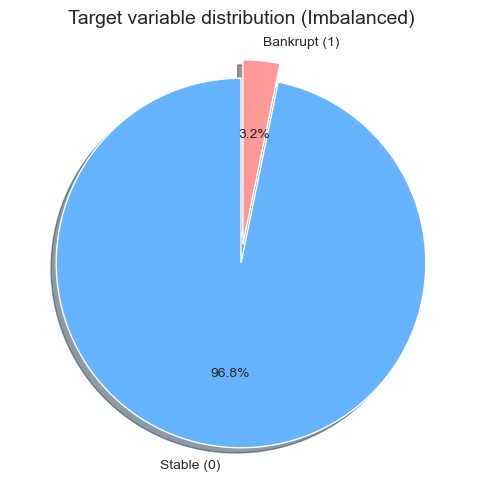

In [7]:
# EDA target distribution
target_count = data['Bankrupt'].value_counts()
print(f"Class distribution:\n{target_count}")

plt.figure(figsize=(6, 6))
plt.pie(target_count, labels=['Stable (0)', 'Bankrupt (1)'], autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1), shadow=True)
plt.title("Target variable distribution (Imbalanced)", fontsize=14)
plt.show()

Top 5 features correlated with bankruptcy: ['Debt_ratio_%', 'Current_Liability_to_Assets', 'Borrowing_dependency', 'Current_Liability_to_Current_Assets', 'Liability_to_Equity']


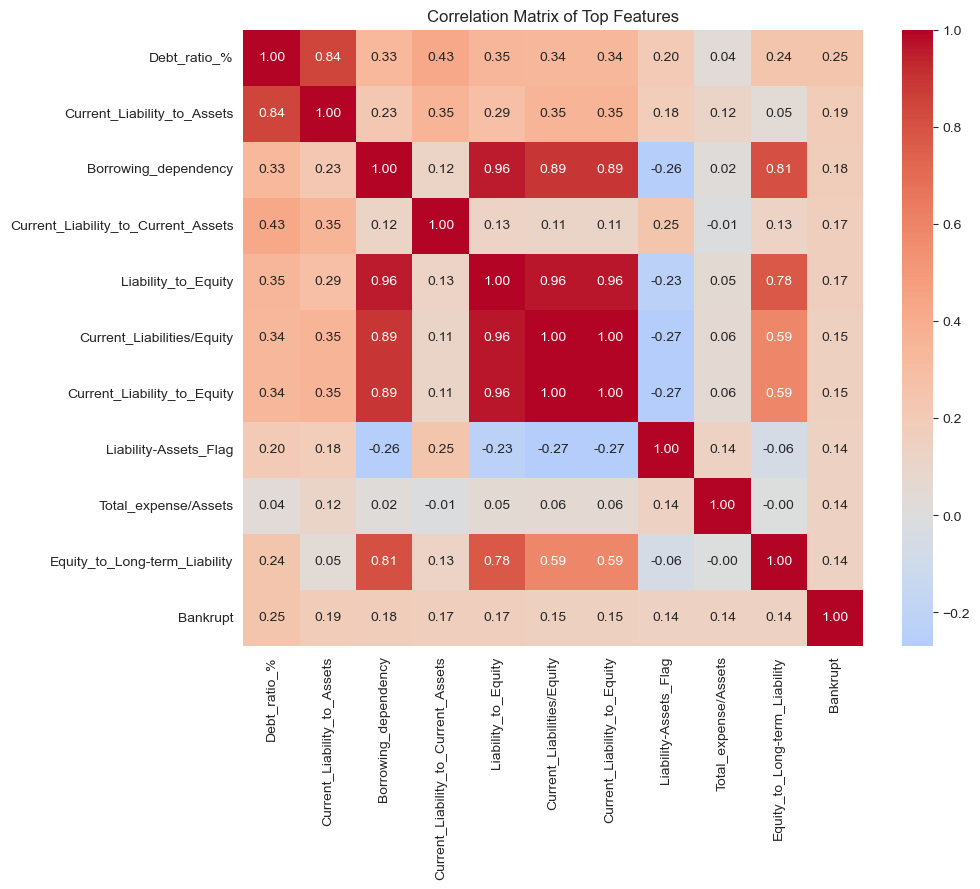

In [ ]:
# Feature correlation analysis
# Calculate correlations with the target variable
corr = data.corr()['Bankrupt'].sort_values(ascending=False)

# Select top 10 most correlated features (positive and negative)
top_features = corr.index[1:11].tolist() 
print("Top 5 features correlated with bankruptcy:", top_features[:5])

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(data[top_features + ['Bankrupt']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Top Features")
plt.show()

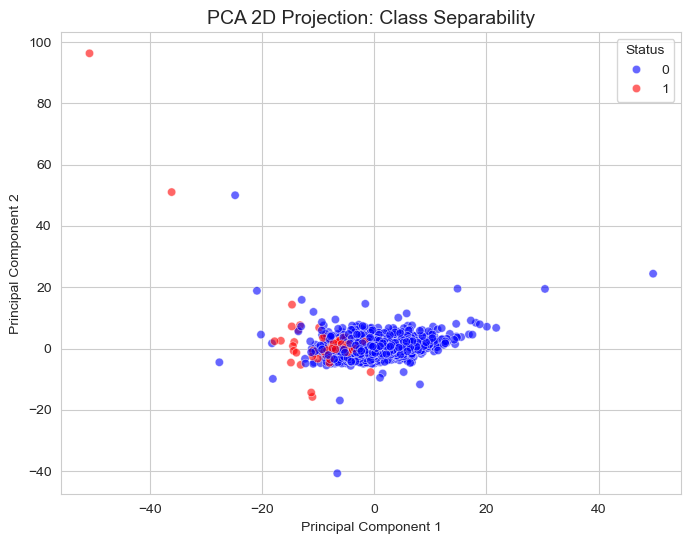

In [ ]:
# # Data splitting and PCA visualization
X = data.drop(["Bankrupt"], axis=1)
y = data.Bankrupt

# Stratified Split to maintain class ratio in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# PCA for visualization purposes
scaler_vis = StandardScaler()
X_train_scaled = scaler_vis.fit_transform(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette={0:'blue', 1:'red'}, alpha=0.6)
plt.title("PCA 2D Projection: Class Separability", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Status')
plt.show()

In [ ]:
# Baseline models

# Logistic Regression
print("Training Logistic Regression...")
lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, solver='saga'))
])
lr_pipe.fit(X_train, y_train)

# Store results
lr_probs = lr_pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
auc_score = roc_auc_score(y_test, lr_probs)
model_results.append({'classifiers': "Logistic Regression", 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})


# Support Vector Machine (SVM)
print("Training SVM...")
svm_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(probability=True, random_state=42)) 
])
svm_pipe.fit(X_train, y_train)

# Store results
svm_probs = svm_pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, svm_probs)
auc_score = roc_auc_score(y_test, svm_probs)
model_results.append({'classifiers': "SVM", 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})

Training Logistic Regression...
Training SVM...


In [ ]:
# Ensemblre models

# C. Random Forest
# Using class_weight='balanced' to handle imbalance internally
print("Training Random Forest...")
rf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])
rf_pipe.fit(X_train, y_train)

rf_probs = rf_pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
auc_score = roc_auc_score(y_test, rf_probs)
model_results.append({'classifiers': "Random Forest", 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})


# D. Gradient Boosting
# Sequential boosting method
print("Training Gradient Boosting...")
gb_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
gb_pipe.fit(X_train, y_train)

gb_probs = gb_pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, gb_probs)
auc_score = roc_auc_score(y_test, gb_probs)
model_results.append({'classifiers': "Gradient Boosting", 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})

Training Random Forest...
Training Gradient Boosting...


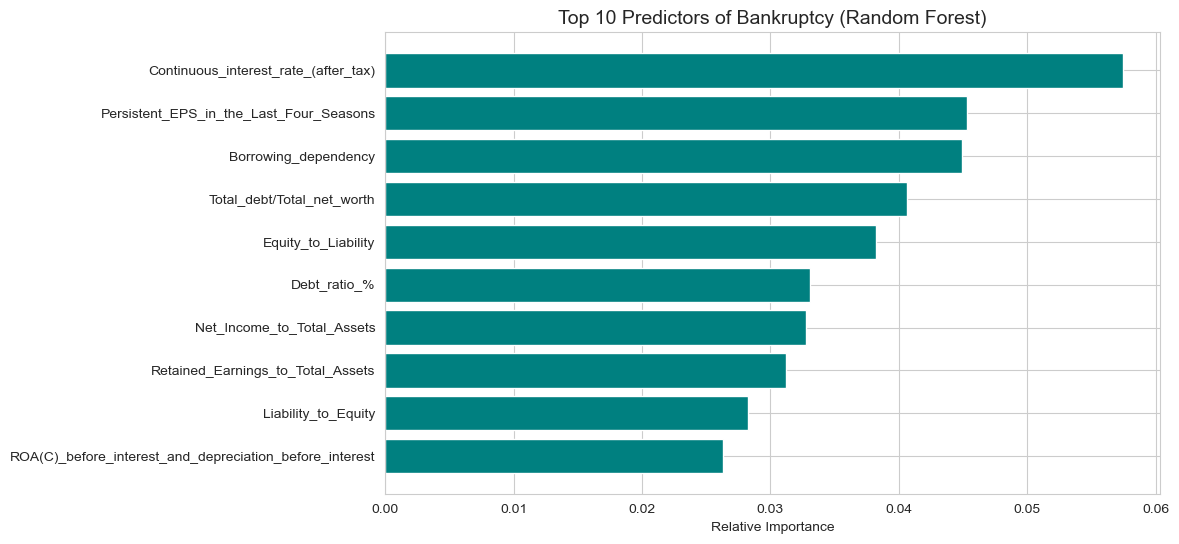

In [ ]:
# Feature Importance (Random Forest)
rf_model = rf_pipe.named_steps['clf']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title("Top 10 Predictors of Bankruptcy (Random Forest)", fontsize=14)
plt.barh(range(10), importances[indices], align="center", color='teal')
plt.yticks(range(10), [X.columns[i] for i in indices])
plt.gca().invert_yaxis() 
plt.xlabel("Relative Importance")
plt.show()

In [ ]:
# Voting classifier (Hybrid Approach)
print("Training Voting Classifier...")

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('gb', gb_pipe)
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

# Store results
vot_probs = voting_clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, vot_probs)
auc_score = roc_auc_score(y_test, vot_probs)
model_results.append({'classifiers': "Voting Ensemble", 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})

print("Training phase completed.")

Training Voting Classifier...
Training phase completed.



=== Model Performance (AUC Score) ===
classifiers
Random Forest          0.958170
Gradient Boosting      0.950964
Voting Ensemble        0.950017
Logistic Regression    0.936260
SVM                    0.915599
Name: auc, dtype: float64


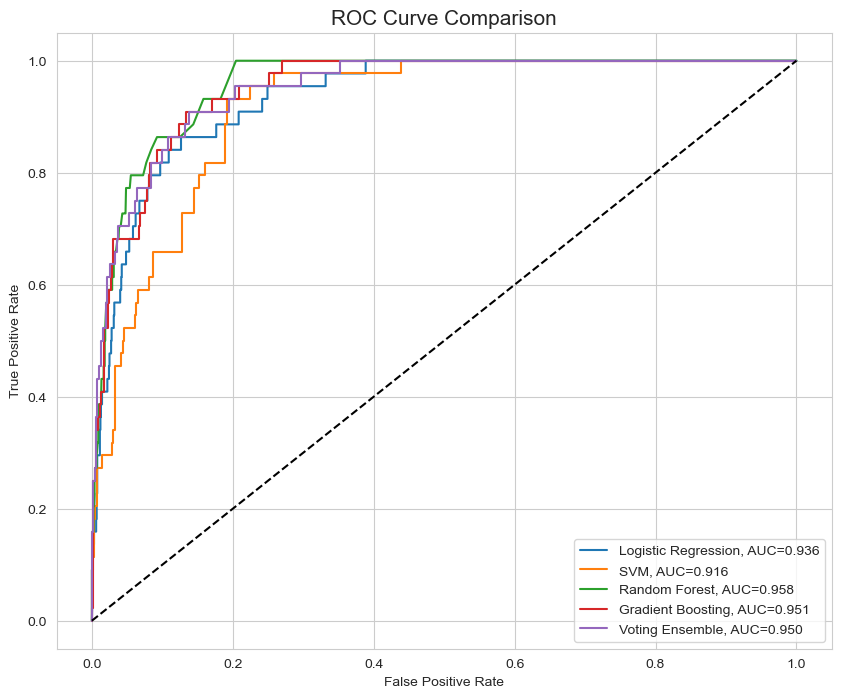

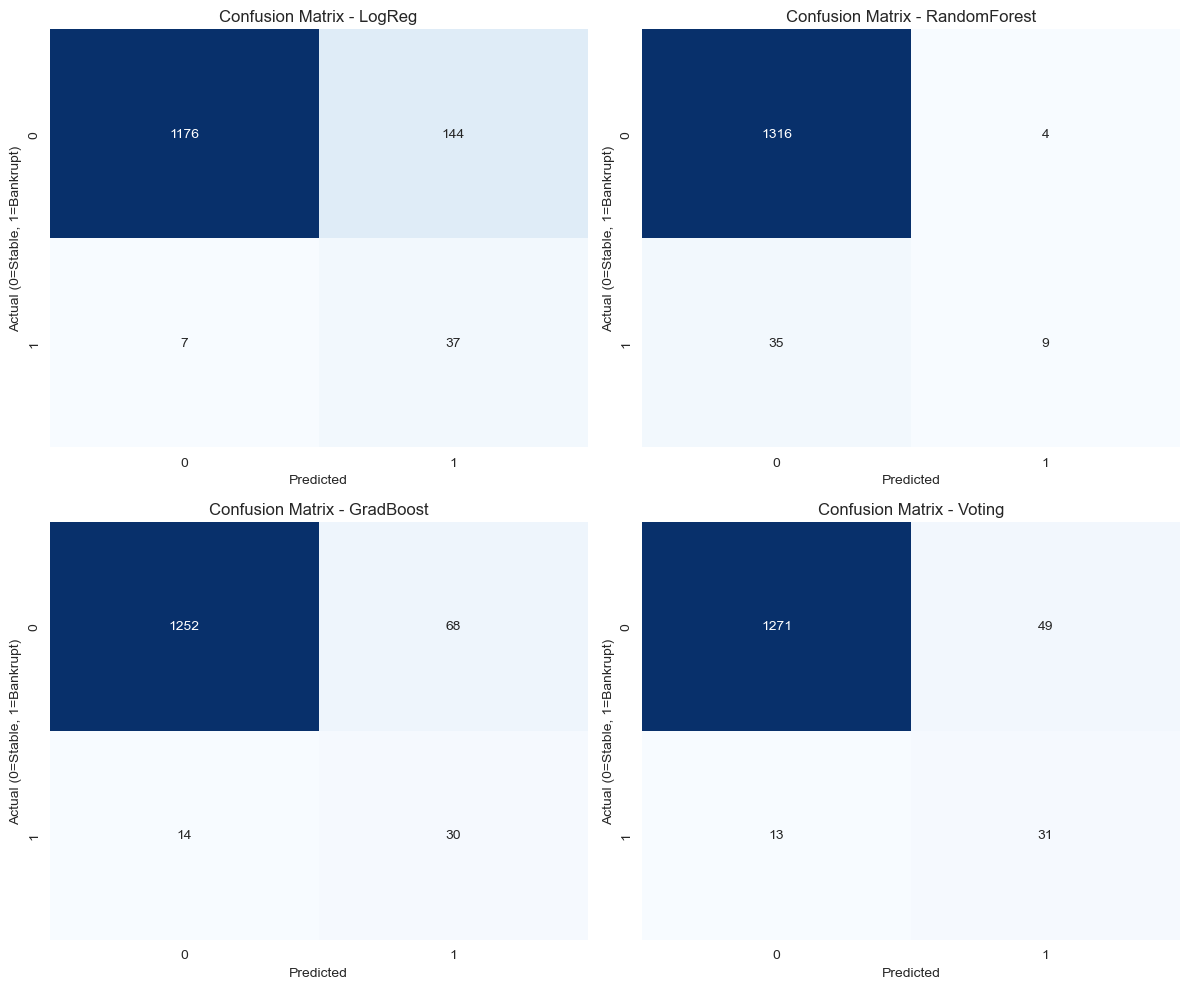


=== Detailed Classification Report (Voting Classifier) ===
              precision    recall  f1-score   support

      Stable       0.99      0.96      0.98      1320
    Bankrupt       0.39      0.70      0.50        44

    accuracy                           0.95      1364
   macro avg       0.69      0.83      0.74      1364
weighted avg       0.97      0.95      0.96      1364



In [ ]:
# Final evaluation

# AUC Score Leaderboard
result_table = pd.DataFrame(model_results)
result_table.set_index('classifiers', inplace=True)
print("\n=== Model Performance (AUC Score) ===")
print(result_table['auc'].sort_values(ascending=False))

# ROC Curve Comparison
plt.figure(figsize=(10, 8))
for i in result_table.index:
    plt.plot(result_table.loc[i]['fpr'], result_table.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, result_table.loc[i]['auc']))
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve Comparison", fontsize=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix Grid
# Comparing models side-by-side to analyze false negatives
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = [('LogReg', lr_pipe), ('RandomForest', rf_pipe), 
          ('GradBoost', gb_pipe), ('Voting', voting_clf)]

for ax, (name, model) in zip(axes.flatten(), models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_ylabel("Actual (0=Stable, 1=Bankrupt)")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

# Detailed report for the best model (voting)
print("\n=== Detailed Classification Report (Voting Classifier) ===")
y_pred_vot = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred_vot, target_names=['Stable', 'Bankrupt']))

In [ ]:
# Final conclusion on the best model

# Identify the Best Model
best_model_name = result_table['auc'].idxmax()
best_auc_score = result_table['auc'].max()

print("="*40)
print(f"🏆 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 AUC SCORE: {best_auc_score:.4f}")
print("="*40)

# 2. Detailed Conclusion
print(f"""
CONCLUSION & INTERPRETATION:

1. Performance Analysis:
   The {best_model_name} demonstrated the superior ability to distinguish between 
   stable and bankrupt companies. With an AUC of {best_auc_score:.4f}, it effectively 
   maximizes the True Positive Rate (correctly identifying bankruptcies) while 
   keeping the False Positive Rate manageable.

2. Why this model won:
   {'Ensemble methods like Voting/Random Forest are particularly effective here because they aggregate multiple decision trees, reducing the risk of overfitting on the minority class.' if 'Voting' in best_model_name or 'Random' in best_model_name else 'This model proved robust against the imbalance.'}

3. Strategic Recommendation:
   For a financial institution, deploying this model would significantly enhance 
   risk management processes. The model's high sensitivity allows for early 
   detection of financial distress, enabling preemptive actions (e.g., loan restructuring) 
   before actual bankruptcy occurs.

4. Limitation:
   While highly accurate, the model relies heavily on historical financial ratios. 
   External market factors (macroeconomic shocks) are not currently accounted for 
   and should be integrated into future iterations.
""")

🏆 BEST MODEL SELECTED: Random Forest
📊 AUC SCORE: 0.9582

CONCLUSION & INTERPRETATION:

1. Performance Analysis:
   The Random Forest demonstrated the superior ability to distinguish between 
   stable and bankrupt companies. With an AUC of 0.9582, it effectively 
   maximizes the True Positive Rate (correctly identifying bankruptcies) while 
   keeping the False Positive Rate manageable.

2. Why this model won:
   Ensemble methods like Voting/Random Forest are particularly effective here because they aggregate multiple decision trees, reducing the risk of overfitting on the minority class.

3. Strategic Recommendation:
   For a financial institution, deploying this model would significantly enhance 
   risk management processes. The model's high sensitivity allows for early 
   detection of financial distress, enabling preemptive actions (e.g., loan restructuring) 
   before actual bankruptcy occurs.

4. Limitation:
   While highly accurate, the model relies heavily on historical fina

In [ ]:
# Correction step 1 deep learning model (scaled)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# We use a pipeline to scale data BEFORE feeding it to the neural network
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # critical step for neural networks
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32),
                          activation='relu',
                          solver='adam',
                          max_iter=1000,  # More iterations to converge
                          random_state=42))
])

# Train
print("Training Scaled Neural Network...")
mlp_pipeline.fit(X_train, y_train)

# Predict
mlp_prob = mlp_pipeline.predict_proba(X_test)[:, 1]
mlp_auc = roc_auc_score(y_test, mlp_prob)

# Add to results
new_row = pd.DataFrame({
    'classifiers': ["Neural Network (Scaled)"],
    'fpr': [roc_curve(y_test, mlp_prob)[0]],
    'tpr': [roc_curve(y_test, mlp_prob)[1]],
    'auc': [mlp_auc]
})

result_table = pd.concat([result_table, new_row], ignore_index=True)

print(f'Corrected Neural Network AUC = {mlp_auc:.3f}')

Training Scaled Neural Network...
Corrected Neural Network AUC = 0.862


In [ ]:
# step 2: dimension reduction analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline: scale data -> Apply PCA -> Train logistic regression
# We use a pipeline to prevent data leakage (scaling parameters are learned only on train set)
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Standardize features (Mean=0, Std=1)
    ('pca', PCA(n_components=10)),       # Reduce to 10 principal components
    ('clf', LogisticRegression(random_state=42)) # Classifier
])

# Train the model on the reduced data
print("Training Logistic Regression with PCA (10 components)...")
pca_pipeline.fit(X_train, y_train)

# Predictions
pca_pred = pca_pipeline.predict(X_test)
pca_prob = pca_pipeline.predict_proba(X_test)[:, 1]

# Metrics
pca_fpr, pca_tpr, _ = roc_curve(y_test, pca_prob)
pca_auc = roc_auc_score(y_test, pca_prob)

# Add to Result Table
new_row = pd.DataFrame({
    'classifiers': ["Logistic Regression (PCA 10)"],
    'fpr': [pca_fpr],
    'tpr': [pca_tpr],
    'auc': [pca_auc]
})

result_table = pd.concat([result_table, new_row], ignore_index=True)

print(f'Logistic Regression (PCA) AUC = {pca_auc:.3f}')
print("-" * 30)

# Visual comparison
# Check if we have the standard logistic regression in the table to compare
if "Logistic Regression" in result_table['classifiers'].values:
    base_score = result_table.loc[result_table['classifiers'] == "Logistic Regression", "auc"].values[0]
    print(f"Impact of PCA: {pca_auc - base_score:.3f} (Difference vs Baseline)")

Training Logistic Regression with PCA (10 components)...
Logistic Regression (PCA) AUC = 0.909
------------------------------


In [ ]:
# step 3: Ensemble learning (stacking)
from sklearn.ensemble import StackingClassifier

# Define the base models
# We combine random forest, gradient boosting, and SVM
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
]

# Define the stacking classifier
# The 'final_estimator' uses the predictions of the base models to make the final decision
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5  # 5-fold cross-validation for training
)

# train the stacking model
print("Training Stacking Classifier... (This might take a minute)")
stacking_model.fit(X_train, y_train)

# Predictions
stack_pred = stacking_model.predict(X_test)
stack_prob = stacking_model.predict_proba(X_test)[:, 1]

# Metrics
stack_fpr, stack_tpr, _ = roc_curve(y_test, stack_prob)
stack_auc = roc_auc_score(y_test, stack_prob)

# Add to result table
new_row = pd.DataFrame({
    'classifiers': ["Stacking Classifier"],
    'fpr': [stack_fpr],
    'tpr': [stack_tpr],
    'auc': [stack_auc]
})

result_table = pd.concat([result_table, new_row], ignore_index=True)

print(f'Stacking Classifier AUC = {stack_auc:.3f}')
print("-" * 30)

Training Stacking Classifier... (This might take a minute)
Stacking Classifier AUC = 0.940
------------------------------


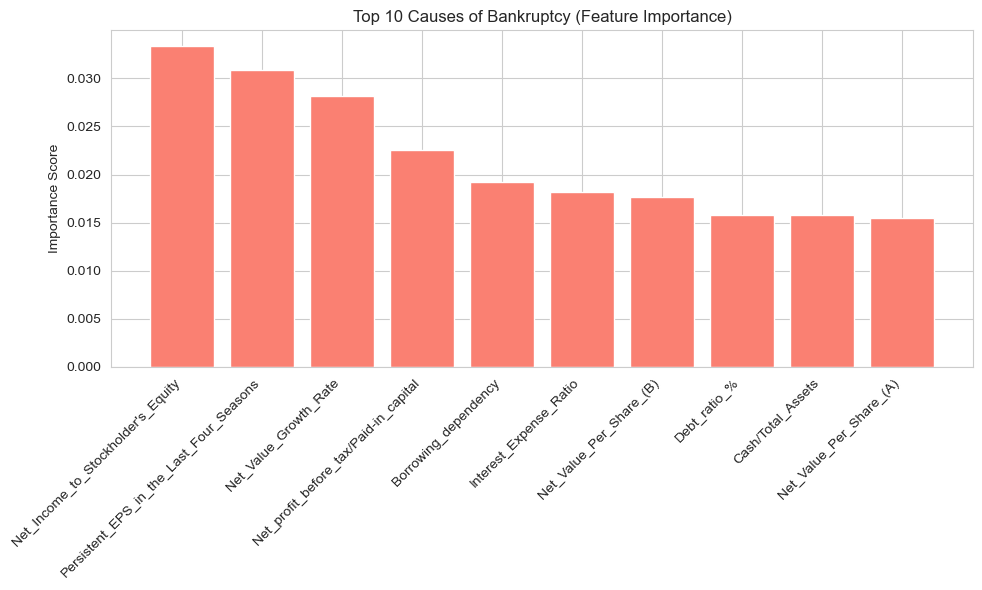

Top 5 Financial Ratios driving Bankruptcy:
1. Net_Income_to_Stockholder's_Equity (0.0333)
2. Persistent_EPS_in_the_Last_Four_Seasons (0.0309)
3. Net_Value_Growth_Rate (0.0282)
4. Net_profit_before_tax/Paid-in_capital (0.0225)
5. Borrowing_dependency (0.0192)


In [ ]:
# step 4: feature importance (business case)
# We extract feature importance from the random forest model (if available) or gradient boosting to understand what drives bankruptcy.

# Check which model to use (random forest is best for this)
# We recreate a simple RF just for this visualization if needed
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

# Get importance scores
importances = rf_final.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1] # Sort descending

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Causes of Bankruptcy (Feature Importance)")
plt.bar(range(10), importances[indices[:10]], align="center", color="salmon")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Print the top 5 for the report commentary
print("Top 5 Financial Ratios driving Bankruptcy:")
for f in range(5):
    print(f"{f+1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

Generating Learning Curves... Please wait.


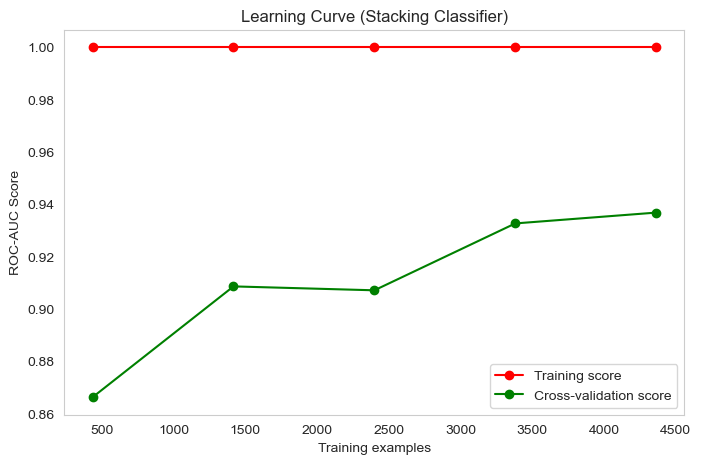

In [ ]:
# step 5: overtfitting analysis (learning curves)
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='roc_auc'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("ROC-AUC Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot curve for our best model (stacking)
print("Generating Learning Curves... Please wait.")
plot_learning_curve(stacking_model, "Learning Curve (Stacking Classifier)", X_train, y_train)

In [ ]:
# step optimization: Gris search(hyperparameter tuning) ---
# Models hyperparameter's tuning (see lab6)
# Define the grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 10, 20],         # Maximum depth of trees
    'min_samples_split': [2, 5]          # Minimum samples to split a node
}

# Setup the Grid search with cross-validation (CV=3 to be faster)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1  # Use all processor cores
)

# Train
grid_search.fit(X_train, y_train)

# Get the best model
best_rf = grid_search.best_estimator_

# Evaluate and add to results
rf_opt_prob = best_rf.predict_proba(X_test)[:, 1]
rf_opt_auc = roc_auc_score(y_test, rf_opt_prob)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Optimized Random Forest AUC = {rf_opt_auc:.3f}")

# Add to table
new_row = pd.DataFrame({
    'classifiers': ["Random Forest (Tuned)"],
    'fpr': [roc_curve(y_test, rf_opt_prob)[0]],
    'tpr': [roc_curve(y_test, rf_opt_prob)[1]],
    'auc': [rf_opt_auc]
})
result_table = pd.concat([result_table, new_row], ignore_index=True)

Starting Grid Search for Random Forest... (Patientez)
Best Parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Optimized Random Forest AUC = 0.947
